In [6]:
# Import required libraries
import numpy as np
import pandas as pd
import pickle
import os
import glob
from scipy import signal, stats
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report, roc_curve, roc_auc_score)
import xgboost as xgb
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully")
print(f"XGBoost version: {xgb.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

All libraries imported successfully
XGBoost version: 3.1.1
NumPy version: 2.3.3
Pandas version: 2.3.3


In [7]:
# Define paths to WESAD dataset
WESAD_PATH = r"c:\Users\ariac\Downloads\WESAD\WESAD"
PKL_PATH = os.path.join(WESAD_PATH, "pkl_files")

# Get list of all pkl files
pkl_files = glob.glob(os.path.join(PKL_PATH, "*.pkl"))
pkl_files.sort()

print(f"WESAD Dataset Information")
print("=" * 50)
print(f"Found {len(pkl_files)} subject files:")
total_size = 0
for file in pkl_files:
    filename = os.path.basename(file)
    size_mb = os.path.getsize(file) / (1024*1024)
    total_size += size_mb
    print(f"  {filename}: {size_mb:.1f} MB")

print(f"\nTotal dataset size: {total_size/1024:.2f} GB")
print(f"Number of subjects: {len(pkl_files)}")
print(f"Average file size: {total_size/len(pkl_files):.1f} MB per subject")

WESAD Dataset Information
Found 15 subject files:
  S10.pkl: 827.0 MB
  S11.pkl: 792.6 MB
  S13.pkl: 844.3 MB
  S14.pkl: 840.3 MB
  S15.pkl: 789.4 MB
  S16.pkl: 857.3 MB
  S17.pkl: 903.1 MB
  S2.pkl: 929.9 MB
  S3.pkl: 983.7 MB
  S4.pkl: 986.4 MB
  S5.pkl: 947.4 MB
  S6.pkl: 1071.3 MB
  S7.pkl: 791.0 MB
  S8.pkl: 829.2 MB
  S9.pkl: 794.1 MB

Total dataset size: 12.88 GB
Number of subjects: 15
Average file size: 879.1 MB per subject


In [8]:
def load_wesad_data(pkl_files):
    """
    Load WESAD dataset from pkl files
    Returns: dict with subject data
    """
    subjects_data = {}
    
    for file in pkl_files:
        subject_id = os.path.basename(file).replace('.pkl', '')
        print(f"Loading {subject_id}...", end=' ')
        
        with open(file, 'rb') as f:
            data = pickle.load(f, encoding='latin1')
            subjects_data[subject_id] = data
            
        # Get label distribution
        labels = data['label']
        unique, counts = np.unique(labels, return_counts=True)
        print(f"Labels: {dict(zip(unique, counts))}")
    
    return subjects_data

# Load all subjects
subjects_data = load_wesad_data(pkl_files)

print(f"\nSuccessfully loaded {len(subjects_data)} subjects")

Loading S10... Labels: {np.int32(0): np.int64(1589000), np.int32(1): np.int64(826000), np.int32(2): np.int64(507500), np.int32(3): np.int64(260400), np.int32(4): np.int64(557200), np.int32(5): np.int64(35700), np.int32(6): np.int64(31500), np.int32(7): np.int64(39900)}
Loading S11... Labels: {np.int32(0): np.int64(1589000), np.int32(1): np.int64(826000), np.int32(2): np.int64(507500), np.int32(3): np.int64(260400), np.int32(4): np.int64(557200), np.int32(5): np.int64(35700), np.int32(6): np.int64(31500), np.int32(7): np.int64(39900)}
Loading S11... Labels: {np.int32(0): np.int64(1443400), np.int32(1): np.int64(826000), np.int32(2): np.int64(476000), np.int32(3): np.int64(257600), np.int32(4): np.int64(553701), np.int32(5): np.int64(35000), np.int32(6): np.int64(36399), np.int32(7): np.int64(35000)}
Loading S13... Labels: {np.int32(0): np.int64(1443400), np.int32(1): np.int64(826000), np.int32(2): np.int64(476000), np.int32(3): np.int64(257600), np.int32(4): np.int64(553701), np.int32(5

## 3. Prepare Binary Classification Dataset

For stress detection, we'll convert the multi-class problem to binary:
- **Stress (1)**: Label 2 (Stress condition from TSST protocol)
- **Non-Stress (0)**: Labels 1, 3, 4 (Baseline, Amusement, Meditation)

**Why include labels 1, 3, 4 for non-stress?**
- Better generalization for real-world deployment
- Captures natural variability in non-stressed emotional states
- More robust model for unseen data
- Real users won't always be in "perfect baseline" state

**Labels excluded from binary classification:**
- **Label 0**: Transient/undefined states
- **Labels 5, 6**: Transition periods
- **Label 7**: Undocumented (data error)

In [9]:
def prepare_binary_classification_data(subjects_data):
    """
    Prepare data for binary stress classification
    - Stress (1): Label 2
    - Non-stress (0): Labels 1, 3, 4
    - Exclude: Labels 0, 5, 6, 7
    """
    all_features = []
    all_labels = []
    all_subjects = []
    
    for subject_id, data in subjects_data.items():
        # Get chest sensor data (most reliable)
        chest = data['signal']['chest']
        labels = data['label']
        
        # Filter for binary classification: keep only labels 1, 2, 3, 4
        valid_mask = np.isin(labels, [1, 2, 3, 4])
        
        # Binary labels: 0 = non-stress (labels 1, 3, 4), 1 = stress (label 2)
        binary_labels = (labels[valid_mask] == 2).astype(int)
        
        # Extract all chest signals for valid samples
        # Available chest signals: ACC, ECG, EMG, EDA, Temp, Resp
        valid_data = {}
        for signal_name, signal_data in chest.items():
            if len(signal_data.shape) == 1:
                # 1D signals
                valid_data[signal_name] = signal_data[valid_mask]
            else:
                # 2D signals (e.g., ACC with x,y,z)
                valid_data[signal_name] = signal_data[valid_mask, :]
        
        # Store
        all_features.append(valid_data)
        all_labels.append(binary_labels)
        all_subjects.append([subject_id] * len(binary_labels))
        
    return all_features, all_labels, all_subjects

# Prepare binary classification dataset
features_list, labels_list, subjects_list = prepare_binary_classification_data(subjects_data)

# Print dataset statistics
print("Binary Classification Dataset Statistics")
print("=" * 60)
for i, (subject_id, labels) in enumerate(zip(subjects_data.keys(), labels_list)):
    stress_samples = np.sum(labels == 1)
    nonstress_samples = np.sum(labels == 0)
    total = len(labels)
    
    print(f"{subject_id}:")
    print(f"  Non-Stress: {nonstress_samples:,} ({nonstress_samples/total*100:.1f}%)")
    print(f"  Stress:     {stress_samples:,} ({stress_samples/total*100:.1f}%)")
    print(f"  Total:      {total:,}")

# Overall statistics
total_stress = sum(np.sum(labels == 1) for labels in labels_list)
total_nonstress = sum(np.sum(labels == 0) for labels in labels_list)
total_samples = total_stress + total_nonstress

print(f"\n{'='*60}")
print(f"Overall Dataset:")
print(f"  Non-Stress (Labels 1,3,4): {total_nonstress:,} ({total_nonstress/total_samples*100:.1f}%)")
print(f"  Stress (Label 2):          {total_stress:,} ({total_stress/total_samples*100:.1f}%)")
print(f"  Total:                     {total_samples:,}")
print(f"  Class Ratio:               {total_nonstress/total_stress:.2f}:1 (non-stress:stress)")

Binary Classification Dataset Statistics
S10:
  Non-Stress: 1,643,600 (76.4%)
  Stress:     507,500 (23.6%)
  Total:      2,151,100
S11:
  Non-Stress: 1,637,301 (77.5%)
  Stress:     476,000 (22.5%)
  Total:      2,113,301
S13:
  Non-Stress: 1,649,900 (78.0%)
  Stress:     464,800 (22.0%)
  Total:      2,114,700
S14:
  Non-Stress: 1,642,201 (77.7%)
  Stress:     472,500 (22.3%)
  Total:      2,114,701
S15:
  Non-Stress: 1,638,699 (77.3%)
  Stress:     480,200 (22.7%)
  Total:      2,118,899
S16:
  Non-Stress: 1,637,999 (77.7%)
  Stress:     471,101 (22.3%)
  Total:      2,109,100
S17:
  Non-Stress: 1,598,800 (76.0%)
  Stress:     506,100 (24.0%)
  Total:      2,104,900
S2:
  Non-Stress: 1,591,799 (78.7%)
  Stress:     430,500 (21.3%)
  Total:      2,022,299
S3:
  Non-Stress: 1,606,501 (78.2%)
  Stress:     448,000 (21.8%)
  Total:      2,054,501
S4:
  Non-Stress: 1,634,501 (78.6%)
  Stress:     444,500 (21.4%)
  Total:      2,079,001
S5:
  Non-Stress: 1,656,200 (78.6%)
  Stress:     45

## 4. Feature Engineering

Extract statistical and frequency-domain features from physiological signals.

In [10]:
def extract_statistical_features(signal):
    """Extract time-domain statistical features from a signal"""
    features = {}
    
    features['mean'] = np.mean(signal)
    features['std'] = np.std(signal)
    features['min'] = np.min(signal)
    features['max'] = np.max(signal)
    features['range'] = features['max'] - features['min']
    
    features['q25'] = np.percentile(signal, 25)
    features['median'] = np.percentile(signal, 50)
    features['q75'] = np.percentile(signal, 75)
    features['iqr'] = features['q75'] - features['q25']
    
    features['skewness'] = stats.skew(signal)
    features['kurtosis'] = stats.kurtosis(signal)
    
    return features


def extract_frequency_features(signal, sampling_rate=700):
    """Extract frequency-domain features using FFT"""
    features = {}
    
    # Compute FFT
    fft_vals = np.fft.fft(signal)
    fft_freq = np.fft.fftfreq(len(signal), 1/sampling_rate)
    
    # Only positive frequencies
    positive_freq_idx = fft_freq > 0
    fft_freq = fft_freq[positive_freq_idx]
    fft_magnitude = np.abs(fft_vals[positive_freq_idx])
    
    # Power spectral density
    psd = fft_magnitude ** 2
    
    # Dominant frequency
    features['dominant_freq'] = fft_freq[np.argmax(psd)]
    
    # Spectral energy
    features['spectral_energy'] = np.sum(psd)
    
    # Spectral entropy
    psd_norm = psd / np.sum(psd)
    features['spectral_entropy'] = -np.sum(psd_norm * np.log2(psd_norm + 1e-12))
    
    # Power in frequency bands
    features['power_vlow'] = np.sum(psd[(fft_freq >= 0) & (fft_freq < 0.5)])
    features['power_low'] = np.sum(psd[(fft_freq >= 0.5) & (fft_freq < 2)])
    features['power_mid'] = np.sum(psd[(fft_freq >= 2) & (fft_freq < 5)])
    features['power_high'] = np.sum(psd[(fft_freq >= 5) & (fft_freq < 10)])
    
    return features


def extract_window_features(signal_data, window_size=700*60, overlap=0.5):
    """
    Extract features from sliding windows
    window_size: samples per window (default: 60 seconds at 700Hz)
    overlap: overlap ratio (0.5 = 50% overlap)
    """
    all_features = []
    
    # Get signal names and prepare for iteration
    signal_names = list(signal_data.keys())
    signal_length = len(signal_data[signal_names[0]])
    
    step = int(window_size * (1 - overlap))
    
    for start_idx in range(0, signal_length - window_size + 1, step):
        end_idx = start_idx + window_size
        window_features = {}
        
        for signal_name, signal in signal_data.items():
            if len(signal.shape) == 1:
                # 1D signal
                window_signal = signal[start_idx:end_idx]
                
                # Statistical features
                stat_features = extract_statistical_features(window_signal)
                for feat_name, feat_val in stat_features.items():
                    window_features[f'{signal_name}_{feat_name}'] = feat_val
                
                # Frequency features (for ECG, EDA, Resp)
                if signal_name in ['ECG', 'EDA', 'Resp']:
                    freq_features = extract_frequency_features(window_signal)
                    for feat_name, feat_val in freq_features.items():
                        window_features[f'{signal_name}_{feat_name}'] = feat_val
                        
            else:
                # 2D signal (e.g., ACC with x,y,z)
                for axis in range(signal.shape[1]):
                    window_signal = signal[start_idx:end_idx, axis]
                    
                    stat_features = extract_statistical_features(window_signal)
                    for feat_name, feat_val in stat_features.items():
                        window_features[f'{signal_name}_axis{axis}_{feat_name}'] = feat_val
        
        all_features.append(window_features)
    
    return all_features


print("Feature extraction functions defined")
print("  - extract_statistical_features()")
print("  - extract_frequency_features()")
print("  - extract_window_features()")

Feature extraction functions defined
  - extract_statistical_features()
  - extract_frequency_features()
  - extract_window_features()


In [11]:
# Extract features for all subjects with sliding windows
print("Extracting features for all subjects...")
print("=" * 60)

X_all = []
y_all = []
subject_ids_all = []

for i, (subject_id, signal_data, labels) in enumerate(zip(subjects_data.keys(), features_list, labels_list)):
    print(f"Processing {subject_id}...", end=' ')
    
    # Extract windowed features
    window_features = extract_window_features(signal_data, window_size=700*60, overlap=0.5)
    
    # For each window, assign the most common label in that window
    window_size = 700*60
    overlap = 0.5
    step = int(window_size * (1 - overlap))
    
    window_labels = []
    for start_idx in range(0, len(labels) - window_size + 1, step):
        end_idx = start_idx + window_size
        window_label = stats.mode(labels[start_idx:end_idx], keepdims=True)[0][0]
        window_labels.append(window_label)
    
    # Convert to DataFrame
    X_subject = pd.DataFrame(window_features)
    y_subject = np.array(window_labels)
    
    X_all.append(X_subject)
    y_all.append(y_subject)
    subject_ids_all.extend([subject_id] * len(y_subject))
    
    print(f"{len(window_features)} windows, {X_subject.shape[1]} features")

# Combine all subjects
X = pd.concat(X_all, ignore_index=True)
y = np.concatenate(y_all)

print(f"\n{'='*60}")
print(f"Feature extraction complete!")
print(f"  Total samples: {len(X):,}")
print(f"  Total features: {X.shape[1]}")
print(f"  Stress samples: {np.sum(y == 1):,} ({np.sum(y == 1)/len(y)*100:.1f}%)")
print(f"  Non-stress samples: {np.sum(y == 0):,} ({np.sum(y == 0)/len(y)*100:.1f}%)")

# Show first few feature names
print(f"\nSample features (first 10):")
for i, col in enumerate(X.columns[:10]):
    print(f"  {i+1}. {col}")

Extracting features for all subjects...
Processing S10... 101 windows, 88 features
Processing S11... 101 windows, 88 features
Processing S11... 99 windows, 88 features
Processing S13... 99 windows, 88 features
Processing S13... 99 windows, 88 features
Processing S14... 99 windows, 88 features
Processing S14... 99 windows, 88 features
Processing S15... 99 windows, 88 features
Processing S15... 99 windows, 88 features
Processing S16... 99 windows, 88 features
Processing S16... 99 windows, 88 features
Processing S17... 99 windows, 88 features
Processing S17... 99 windows, 88 features
Processing S2... 99 windows, 88 features
Processing S2... 95 windows, 88 features
Processing S3... 95 windows, 88 features
Processing S3... 96 windows, 88 features
Processing S4... 96 windows, 88 features
Processing S4... 98 windows, 88 features
Processing S5... 98 windows, 88 features
Processing S5... 99 windows, 88 features
Processing S6... 99 windows, 88 features
Processing S6... 98 windows, 88 features
Pr

## 5. Data Preprocessing & Train-Test Split

In [12]:
# Split dataset: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Dataset Split")
print("=" * 60)
print(f"Training set:")
print(f"  Samples: {len(X_train):,}")
print(f"  Stress: {np.sum(y_train == 1):,} ({np.sum(y_train == 1)/len(y_train)*100:.1f}%)")
print(f"  Non-stress: {np.sum(y_train == 0):,} ({np.sum(y_train == 0)/len(y_train)*100:.1f}%)")

print(f"\nTest set:")
print(f"  Samples: {len(X_test):,}")
print(f"  Stress: {np.sum(y_test == 1):,} ({np.sum(y_test == 1)/len(y_test)*100:.1f}%)")
print(f"  Non-stress: {np.sum(y_test == 0):,} ({np.sum(y_test == 0)/len(y_test)*100:.1f}%)")

# Normalize features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to preserve column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print(f"\nData preprocessing complete")
print(f"  Features normalized using StandardScaler")

Dataset Split
Training set:
  Samples: 1,180
  Stress: 262 (22.2%)
  Non-stress: 918 (77.8%)

Test set:
  Samples: 296
  Stress: 66 (22.3%)
  Non-stress: 230 (77.7%)

Data preprocessing complete
  Features normalized using StandardScaler


## 6. XGBoost Model Training

In [13]:
# Initialize XGBoost classifier with optimized parameters
xgb_model = XGBClassifier(
    n_estimators=200,           # Number of boosting rounds
    max_depth=6,                # Maximum tree depth
    learning_rate=0.1,          # Step size shrinkage
    subsample=0.8,              # Subsample ratio of training instances
    colsample_bytree=0.8,       # Subsample ratio of features
    min_child_weight=1,         # Minimum sum of instance weight in a child
    gamma=0.1,                  # Minimum loss reduction for split
    reg_alpha=0.01,             # L1 regularization
    reg_lambda=1.0,             # L2 regularization
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

print("Training XGBoost Classifier...")
print("=" * 60)

# Train the model
import time
start_time = time.time()

xgb_model.fit(
    X_train_scaled, 
    y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    verbose=50
)

training_time = time.time() - start_time

print(f"\nTraining complete in {training_time:.2f} seconds")
print(f"  Model: XGBoost Classifier")
print(f"  Training samples: {len(X_train):,}")
print(f"  Features: {X_train.shape[1]}")

Training XGBoost Classifier...
[0]	validation_0-logloss:0.46059	validation_1-logloss:0.46584
[0]	validation_0-logloss:0.46059	validation_1-logloss:0.46584
[50]	validation_0-logloss:0.01858	validation_1-logloss:0.05460
[50]	validation_0-logloss:0.01858	validation_1-logloss:0.05460
[100]	validation_0-logloss:0.00711	validation_1-logloss:0.04048
[100]	validation_0-logloss:0.00711	validation_1-logloss:0.04048
[150]	validation_0-logloss:0.00486	validation_1-logloss:0.03676
[150]	validation_0-logloss:0.00486	validation_1-logloss:0.03676
[199]	validation_0-logloss:0.00407	validation_1-logloss:0.03580

Training complete in 0.55 seconds
  Model: XGBoost Classifier
  Training samples: 1,180
  Features: 88
[199]	validation_0-logloss:0.00407	validation_1-logloss:0.03580

Training complete in 0.55 seconds
  Model: XGBoost Classifier
  Training samples: 1,180
  Features: 88


## 7. Model Evaluation

Comprehensive evaluation using multiple metrics and visualizations.

In [14]:
# Make predictions
y_pred = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)
roc_auc = metrics.roc_auc_score(y_test, y_pred_proba)

# Print metrics
print("XGBoost Performance Metrics")
print("=" * 60)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# Confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f"  TN: {cm[0,0]:,}  |  FP: {cm[0,1]:,}")
print(f"  FN: {cm[1,0]:,}  |  TP: {cm[1,1]:,}")

# Classification report
print(f"\nDetailed Classification Report:")
print(metrics.classification_report(y_test, y_pred, target_names=['Non-Stress', 'Stress']))

XGBoost Performance Metrics
Accuracy:  0.9831 (98.31%)
Precision: 0.9420
Recall:    0.9848
F1-Score:  0.9630
ROC-AUC:   0.9990

Confusion Matrix:
  TN: 226  |  FP: 4
  FN: 1  |  TP: 65

Detailed Classification Report:
              precision    recall  f1-score   support

  Non-Stress       1.00      0.98      0.99       230
      Stress       0.94      0.98      0.96        66

    accuracy                           0.98       296
   macro avg       0.97      0.98      0.98       296
weighted avg       0.98      0.98      0.98       296


Accuracy:  0.9831 (98.31%)
Precision: 0.9420
Recall:    0.9848
F1-Score:  0.9630
ROC-AUC:   0.9990

Confusion Matrix:
  TN: 226  |  FP: 4
  FN: 1  |  TP: 65

Detailed Classification Report:
              precision    recall  f1-score   support

  Non-Stress       1.00      0.98      0.99       230
      Stress       0.94      0.98      0.96        66

    accuracy                           0.98       296
   macro avg       0.97      0.98      0.98   

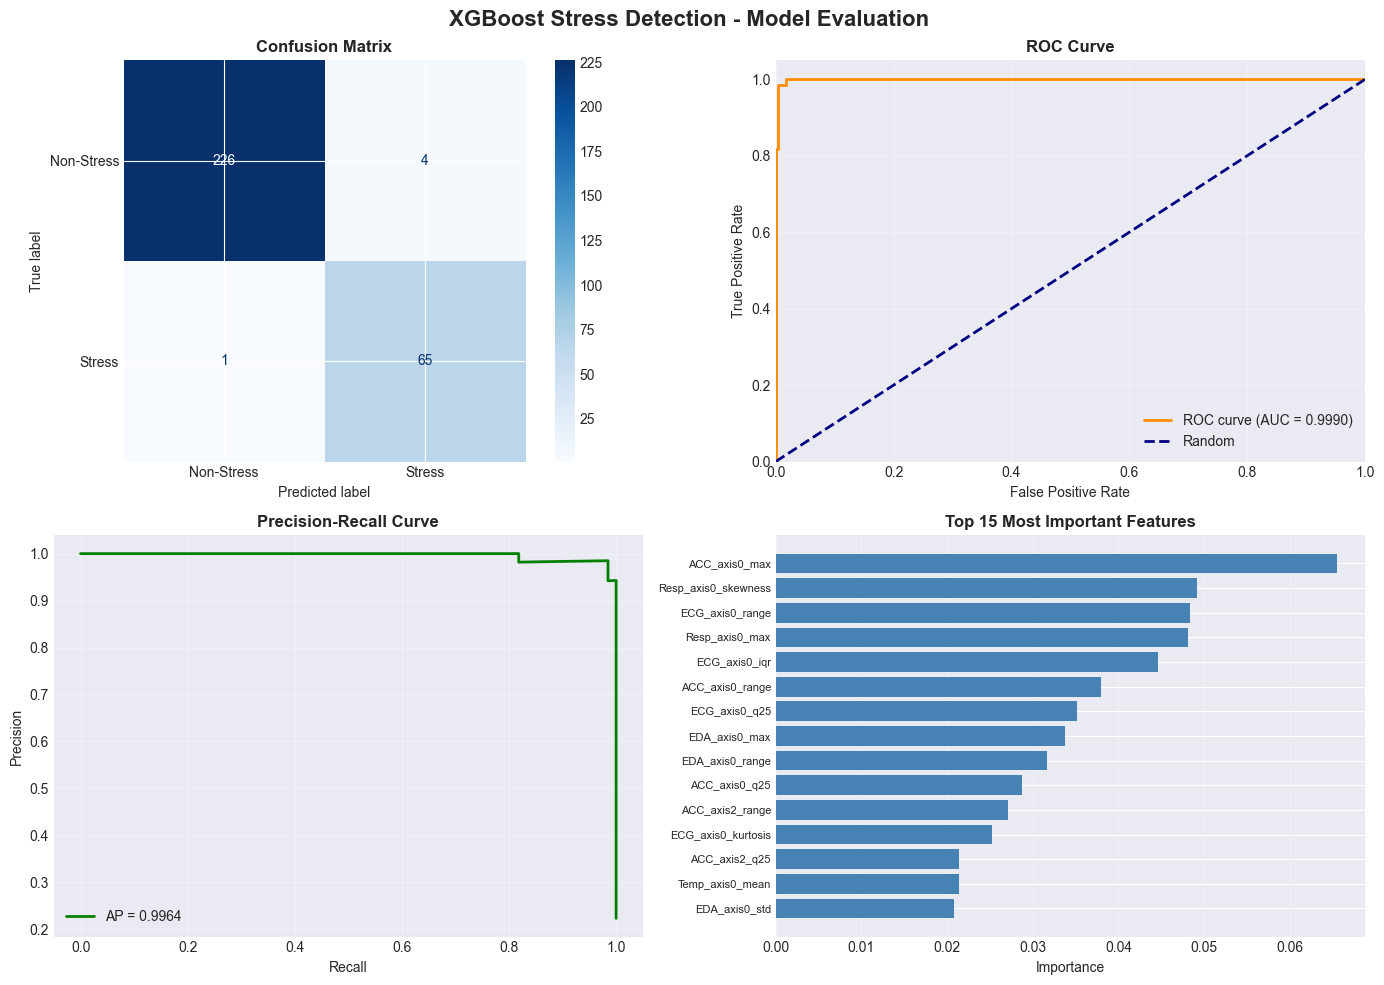

In [15]:
# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('XGBoost Stress Detection - Model Evaluation', fontsize=16, fontweight='bold')

# 1. Confusion Matrix Heatmap
from sklearn.metrics import ConfusionMatrixDisplay
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Stress', 'Stress'])
cm_display.plot(ax=axes[0, 0], cmap='Blues', values_format='d')
axes[0, 0].set_title('Confusion Matrix', fontweight='bold')

# 2. ROC Curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_proba)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve', fontweight='bold')
axes[0, 1].legend(loc="lower right")
axes[0, 1].grid(alpha=0.3)

# 3. Precision-Recall Curve
precision_curve, recall_curve, _ = metrics.precision_recall_curve(y_test, y_pred_proba)
avg_precision = metrics.average_precision_score(y_test, y_pred_proba)
axes[1, 0].plot(recall_curve, precision_curve, color='green', lw=2, label=f'AP = {avg_precision:.4f}')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve', fontweight='bold')
axes[1, 0].legend(loc="lower left")
axes[1, 0].grid(alpha=0.3)

# 4. Feature Importance (Top 15)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

top_15_features = feature_importance.head(15)
axes[1, 1].barh(range(len(top_15_features)), top_15_features['importance'], color='steelblue')
axes[1, 1].set_yticks(range(len(top_15_features)))
axes[1, 1].set_yticklabels(top_15_features['feature'], fontsize=8)
axes[1, 1].invert_yaxis()
axes[1, 1].set_xlabel('Importance')
axes[1, 1].set_title('Top 15 Most Important Features', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Leave-One-Subject-Out (LOSO) Cross-Validation

LOSO CV provides realistic subject-independent performance by training on 14 subjects and testing on 1 held-out subject, repeated for all 15 subjects. This prevents data leakage from having the same subject's data in both training and test sets.

In [16]:
# Prepare subject IDs array for LOSO CV
subject_ids_array = np.array(subject_ids_all)
unique_subjects = np.unique(subject_ids_array)

print("Starting Leave-One-Subject-Out Cross-Validation...")
print("=" * 60)
print(f"Total subjects: {len(unique_subjects)}")
print(f"Training strategy: Train on 14 subjects, test on 1 subject")
print(f"Iterations: {len(unique_subjects)} (one for each subject)\n")

# Initialize XGBoost for LOSO
xgb_loso = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0.1,
    reg_alpha=0.01,
    reg_lambda=1.0,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# Store results for each fold
loso_results = []
loso_accuracies = []
loso_f1_scores = []
loso_roc_aucs = []
loso_precisions = []
loso_recalls = []

# LOSO Cross-Validation Loop
for fold_idx, test_subject in enumerate(unique_subjects, 1):
    print(f"[Fold {fold_idx}/{len(unique_subjects)}] Testing on {test_subject}...", end=' ')
    
    # Split data by subject
    test_mask = subject_ids_array == test_subject
    train_mask = ~test_mask
    
    X_train_loso = X.iloc[train_mask]
    X_test_loso = X.iloc[test_mask]
    y_train_loso = y[train_mask]
    y_test_loso = y[test_mask]
    
    # Normalize features
    scaler_loso = StandardScaler()
    X_train_loso_scaled = scaler_loso.fit_transform(X_train_loso)
    X_test_loso_scaled = scaler_loso.transform(X_test_loso)
    
    # Train model
    xgb_loso.fit(X_train_loso_scaled, y_train_loso, verbose=False)
    
    # Make predictions
    y_pred_loso = xgb_loso.predict(X_test_loso_scaled)
    y_pred_proba_loso = xgb_loso.predict_proba(X_test_loso_scaled)[:, 1]
    
    # Calculate metrics
    acc = accuracy_score(y_test_loso, y_pred_loso)
    prec = precision_score(y_test_loso, y_pred_loso, zero_division=0)
    rec = recall_score(y_test_loso, y_pred_loso, zero_division=0)
    f1 = f1_score(y_test_loso, y_pred_loso, zero_division=0)
    roc_auc = roc_auc_score(y_test_loso, y_pred_proba_loso)
    
    # Store results
    loso_results.append({
        'subject': test_subject,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'test_samples': len(y_test_loso),
        'stress_samples': np.sum(y_test_loso == 1),
        'nonstress_samples': np.sum(y_test_loso == 0)
    })
    
    loso_accuracies.append(acc)
    loso_f1_scores.append(f1)
    loso_roc_aucs.append(roc_auc)
    loso_precisions.append(prec)
    loso_recalls.append(rec)
    
    print(f"Acc: {acc:.4f}, F1: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")

# Convert results to DataFrame
loso_results_df = pd.DataFrame(loso_results)

print(f"\n{'='*60}")
print("LOSO Cross-Validation Results Summary")
print("=" * 60)
print(f"Mean Accuracy:  {np.mean(loso_accuracies):.4f} ± {np.std(loso_accuracies):.4f}")
print(f"Mean Precision: {np.mean(loso_precisions):.4f} ± {np.std(loso_precisions):.4f}")
print(f"Mean Recall:    {np.mean(loso_recalls):.4f} ± {np.std(loso_recalls):.4f}")
print(f"Mean F1-Score:  {np.mean(loso_f1_scores):.4f} ± {np.std(loso_f1_scores):.4f}")
print(f"Mean ROC-AUC:   {np.mean(loso_roc_aucs):.4f} ± {np.std(loso_roc_aucs):.4f}")

print(f"\nPer-Subject Performance:")
print(loso_results_df.to_string(index=False))

print(f"\nLOSO Cross-Validation Complete!")
print(f"   Subject-independent performance: {np.mean(loso_accuracies)*100:.2f}% accuracy")

Starting Leave-One-Subject-Out Cross-Validation...
Total subjects: 15
Training strategy: Train on 14 subjects, test on 1 subject
Iterations: 15 (one for each subject)

[Fold 1/15] Testing on S10... Acc: 0.9406, F1: 0.8571, ROC-AUC: 0.9643
[Fold 2/15] Testing on S11... Acc: 0.9406, F1: 0.8571, ROC-AUC: 0.9643
[Fold 2/15] Testing on S11... Acc: 0.9091, F1: 0.8302, ROC-AUC: 0.9982
[Fold 3/15] Testing on S13... Acc: 0.9091, F1: 0.8302, ROC-AUC: 0.9982
[Fold 3/15] Testing on S13... Acc: 0.8788, F1: 0.6250, ROC-AUC: 0.9805
[Fold 4/15] Testing on S14... Acc: 0.8788, F1: 0.6250, ROC-AUC: 0.9805
[Fold 4/15] Testing on S14... Acc: 0.9192, F1: 0.8462, ROC-AUC: 0.9723
[Fold 5/15] Testing on S15... Acc: 0.9192, F1: 0.8462, ROC-AUC: 0.9723
[Fold 5/15] Testing on S15... Acc: 0.8889, F1: 0.6857, ROC-AUC: 0.9805
[Fold 6/15] Testing on S16... Acc: 0.8889, F1: 0.6857, ROC-AUC: 0.9805
[Fold 6/15] Testing on S16... Acc: 0.9192, F1: 0.8462, ROC-AUC: 1.0000
[Fold 7/15] Testing on S17... Acc: 0.9192, F1: 0.84

## 9. LOSO Model Evaluation

Evaluate LOSO cross-validation results using the same metrics as Section 7 for direct comparison.

In [17]:
# Aggregate all LOSO predictions for overall evaluation
# Re-run LOSO to collect all predictions
print("Collecting LOSO predictions for comprehensive evaluation...")
print("=" * 60)

all_y_test_loso = []
all_y_pred_loso = []
all_y_pred_proba_loso = []

for fold_idx, test_subject in enumerate(unique_subjects, 1):
    print(f"[Fold {fold_idx}/{len(unique_subjects)}] {test_subject}...", end=' ')
    
    # Split data by subject
    test_mask = subject_ids_array == test_subject
    train_mask = ~test_mask
    
    X_train_loso = X.iloc[train_mask]
    X_test_loso = X.iloc[test_mask]
    y_train_loso = y[train_mask]
    y_test_loso = y[test_mask]
    
    # Normalize features
    scaler_loso = StandardScaler()
    X_train_loso_scaled = scaler_loso.fit_transform(X_train_loso)
    X_test_loso_scaled = scaler_loso.transform(X_test_loso)
    
    # Train model
    xgb_loso_eval = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8,
        colsample_bytree=0.8, min_child_weight=1, gamma=0.1,
        reg_alpha=0.01, reg_lambda=1.0, random_state=42,
        eval_metric='logloss', use_label_encoder=False
    )
    xgb_loso_eval.fit(X_train_loso_scaled, y_train_loso, verbose=False)
    
    # Make predictions
    y_pred_loso = xgb_loso_eval.predict(X_test_loso_scaled)
    y_pred_proba_loso = xgb_loso_eval.predict_proba(X_test_loso_scaled)[:, 1]
    
    # Store predictions
    all_y_test_loso.extend(y_test_loso)
    all_y_pred_loso.extend(y_pred_loso)
    all_y_pred_proba_loso.extend(y_pred_proba_loso)
    
    print(f"done")

# Convert to arrays
all_y_test_loso = np.array(all_y_test_loso)
all_y_pred_loso = np.array(all_y_pred_loso)
all_y_pred_proba_loso = np.array(all_y_pred_proba_loso)

print(f"\nLOSO predictions collected!")
print(f"   Total test samples: {len(all_y_test_loso):,}")

[Fold 1/15] S10... done
[Fold 2/15] S11... done
[Fold 2/15] S11... done
[Fold 3/15] S13... done
[Fold 3/15] S13... done
[Fold 4/15] S14... done
[Fold 4/15] S14... done
[Fold 5/15] S15... done
[Fold 5/15] S15... done
[Fold 6/15] S16... done
[Fold 6/15] S16... done
[Fold 7/15] S17... done
[Fold 7/15] S17... done
[Fold 8/15] S2... done
[Fold 8/15] S2... done
[Fold 9/15] S3... done
[Fold 9/15] S3... done
[Fold 10/15] S4... done
[Fold 10/15] S4... done
[Fold 11/15] S5... done
[Fold 11/15] S5... done
[Fold 12/15] S6... done
[Fold 12/15] S6... done
[Fold 13/15] S7... done
[Fold 13/15] S7... done
[Fold 14/15] S8... done
[Fold 14/15] S8... done
[Fold 15/15] S9... done
[Fold 15/15] S9... done

LOSO predictions collected!
   Total test samples: 1,476
done

LOSO predictions collected!
   Total test samples: 1,476


In [18]:
# Calculate LOSO metrics (same as Section 7)
loso_accuracy = metrics.accuracy_score(all_y_test_loso, all_y_pred_loso)
loso_precision = metrics.precision_score(all_y_test_loso, all_y_pred_loso)
loso_recall = metrics.recall_score(all_y_test_loso, all_y_pred_loso)
loso_f1 = metrics.f1_score(all_y_test_loso, all_y_pred_loso)
loso_roc_auc = metrics.roc_auc_score(all_y_test_loso, all_y_pred_proba_loso)

# Print metrics (same format as Section 7)
print("LOSO Cross-Validation Performance Metrics")
print("=" * 60)
print(f"Accuracy:  {loso_accuracy:.4f} ({loso_accuracy*100:.2f}%)")
print(f"Precision: {loso_precision:.4f}")
print(f"Recall:    {loso_recall:.4f}")
print(f"F1-Score:  {loso_f1:.4f}")
print(f"ROC-AUC:   {loso_roc_auc:.4f}")

# Confusion matrix
loso_cm = metrics.confusion_matrix(all_y_test_loso, all_y_pred_loso)
print(f"\nConfusion Matrix:")
print(f"  TN: {loso_cm[0,0]:,}  |  FP: {loso_cm[0,1]:,}")
print(f"  FN: {loso_cm[1,0]:,}  |  TP: {loso_cm[1,1]:,}")

# Classification report
print(f"\nDetailed Classification Report:")
print(metrics.classification_report(all_y_test_loso, all_y_pred_loso, target_names=['Non-Stress', 'Stress']))

LOSO Cross-Validation Performance Metrics
Accuracy:  0.9119 (91.19%)
Precision: 0.8462
Recall:    0.7378
F1-Score:  0.7883
ROC-AUC:   0.9517

Confusion Matrix:
  TN: 1,104  |  FP: 44
  FN: 86  |  TP: 242

Detailed Classification Report:
              precision    recall  f1-score   support

  Non-Stress       0.93      0.96      0.94      1148
      Stress       0.85      0.74      0.79       328

    accuracy                           0.91      1476
   macro avg       0.89      0.85      0.87      1476
weighted avg       0.91      0.91      0.91      1476



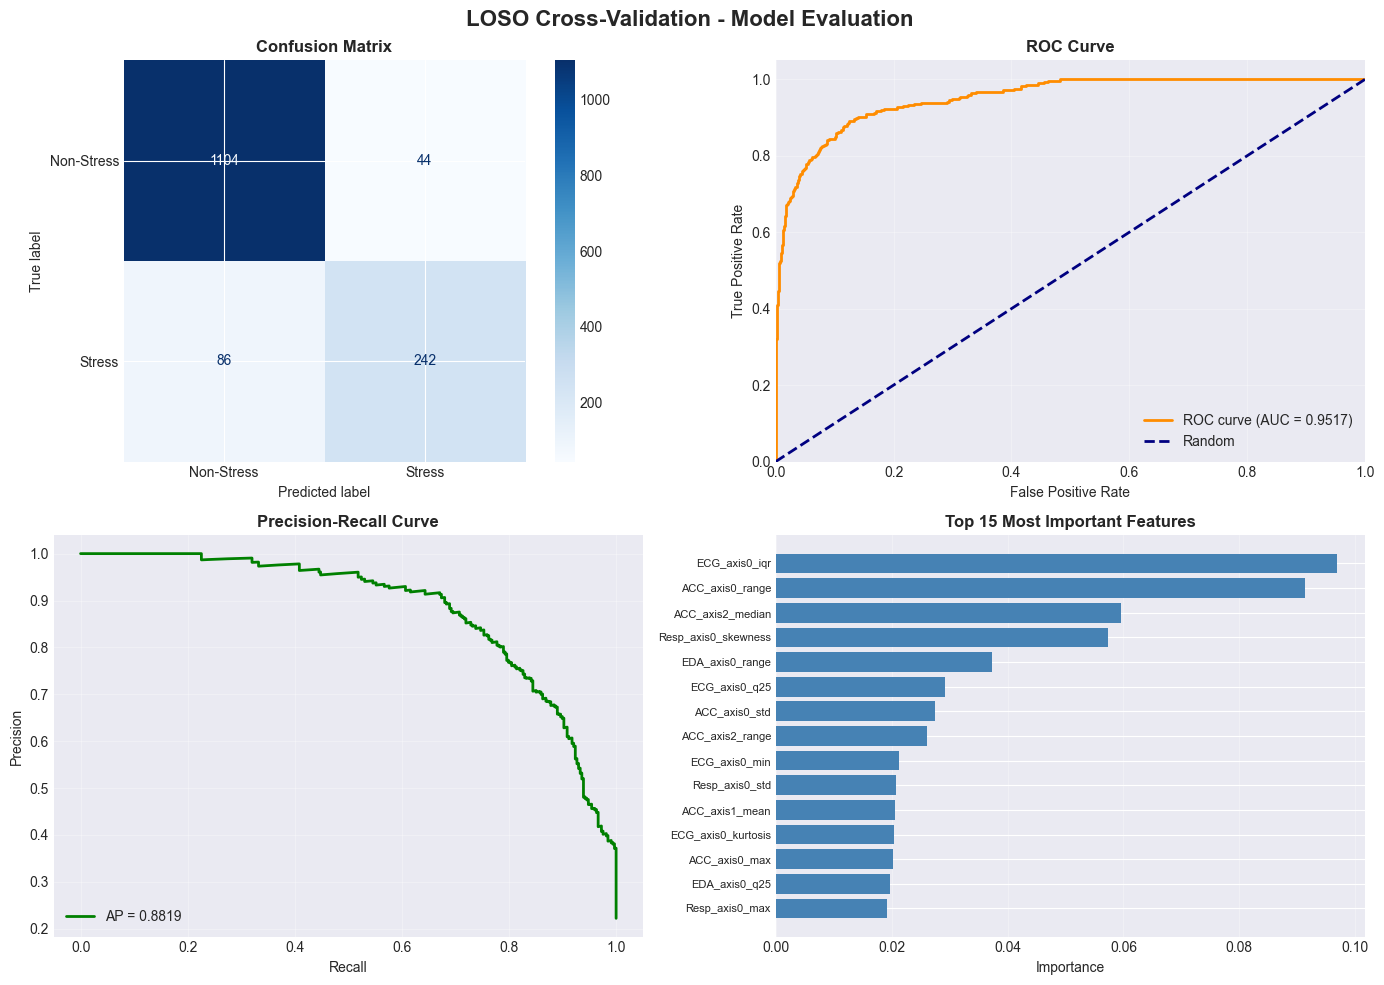


LOSO evaluation visualization complete!


In [19]:
# Visualize LOSO results (same layout as Section 7)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LOSO Cross-Validation - Model Evaluation', fontsize=16, fontweight='bold')

# 1. Confusion Matrix Heatmap
from sklearn.metrics import ConfusionMatrixDisplay
loso_cm_display = ConfusionMatrixDisplay(confusion_matrix=loso_cm, display_labels=['Non-Stress', 'Stress'])
loso_cm_display.plot(ax=axes[0, 0], cmap='Blues', values_format='d')
axes[0, 0].set_title('Confusion Matrix', fontweight='bold')

# 2. ROC Curve
loso_fpr, loso_tpr, loso_thresholds = metrics.roc_curve(all_y_test_loso, all_y_pred_proba_loso)
axes[0, 1].plot(loso_fpr, loso_tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {loso_roc_auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve', fontweight='bold')
axes[0, 1].legend(loc="lower right")
axes[0, 1].grid(alpha=0.3)

# 3. Precision-Recall Curve
loso_precision_curve, loso_recall_curve, _ = metrics.precision_recall_curve(all_y_test_loso, all_y_pred_proba_loso)
loso_avg_precision = metrics.average_precision_score(all_y_test_loso, all_y_pred_proba_loso)
axes[1, 0].plot(loso_recall_curve, loso_precision_curve, color='green', lw=2, label=f'AP = {loso_avg_precision:.4f}')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve', fontweight='bold')
axes[1, 0].legend(loc="lower left")
axes[1, 0].grid(alpha=0.3)

# 4. Feature Importance (Top 15) - using last LOSO fold model
loso_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_loso_eval.feature_importances_
}).sort_values('importance', ascending=False)

loso_top_15_features = loso_feature_importance.head(15)
axes[1, 1].barh(range(len(loso_top_15_features)), loso_top_15_features['importance'], color='steelblue')
axes[1, 1].set_yticks(range(len(loso_top_15_features)))
axes[1, 1].set_yticklabels(loso_top_15_features['feature'], fontsize=8)
axes[1, 1].invert_yaxis()
axes[1, 1].set_xlabel('Importance')
axes[1, 1].set_title('Top 15 Most Important Features', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nLOSO evaluation visualization complete!")

In [20]:
# Save the trained model, scaler, and feature names for the AI Engine
import pickle
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Prepare checkpoint dictionary
# We use the 'xgb_model' trained in Section 6 and 'scaler' from Section 5
checkpoint = {
    'model': xgb_model,
    'scaler': scaler,
    'feature_names': list(X.columns)
}

model_path = os.path.join('models', 'xgboost_stress_model.pkl')

print(f"Saving model checkpoint to {model_path}...")
with open(model_path, 'wb') as f:
    pickle.dump(checkpoint, f)

print("Success! Model saved and ready for AI Engine.")

Saving model checkpoint to models\xgboost_stress_model.pkl...
Success! Model saved and ready for AI Engine.
